In [40]:
import warnings
warnings.filterwarnings('ignore')
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [42]:
df = pd.read_csv('customer_support_text_classification.csv')

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Number of Records:
1500
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')
Target Classes:
['neutral' 'positive' 'negative']
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object
Average Text Length:
72.75666666666666


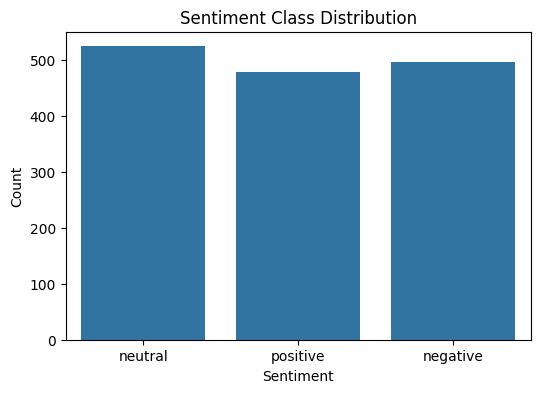

In [43]:
print("Number of Records:")
print(df.shape[0])
print(df.columns)
print("Target Classes:")
print(df['sentiment_label'].unique())
print(df['customer_message'].head())
df['text_length'] = df['customer_message'].apply(len)

print("Average Text Length:")
print(df['text_length'].mean())
plt.figure(figsize=(6,4))

sns.countplot(x=df['sentiment_label'])

plt.title('Sentiment Class Distribution')

plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

In [44]:
stop_words = set(stopwords.words('english'))
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join tokens
    cleaned_text = ' '.join(tokens)

    return cleaned_text
df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text']).toarray()

y = df['sentiment_label']

Machine learning models cannot understand raw text directly.

Text must be converted into numerical vectors so that
models can process patterns mathematically.

TF-IDF converts words into numerical importance scores
based on frequency and uniqueness.

In [45]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [47]:
baseline_model = LogisticRegression()

baseline_model.fit(X_train, y_train)

LogisticRegression()

In [48]:
y_pred = baseline_model.predict(X_test)

Baseline Accuracy:
0.9733333333333334


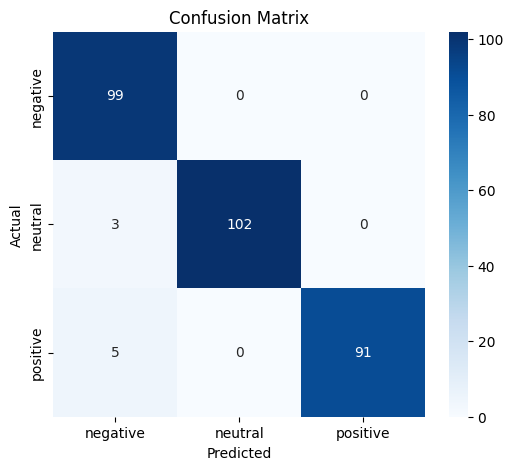

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96        99
     neutral       1.00      0.97      0.99       105
    positive       1.00      0.95      0.97        96

    accuracy                           0.97       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.97      0.97       300



In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:")
print(accuracy)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

In [50]:
evaluation_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Value': [accuracy]
})

evaluation_df.to_csv(
    'results/model_evaluation.csv',
    index=False
)

print("Evaluation file saved.")

Evaluation file saved.


In [51]:
MAX_WORDS = 5000
MAX_LENGTH = 50

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(
    df['cleaned_text']
)
X_seq = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

In [52]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [53]:
lstm_model = Sequential()

# Embedding Layer
lstm_model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    )
)

# LSTM Layer
lstm_model.add(
    LSTM(64)
)

# Dropout
lstm_model.add(
    Dropout(0.3)
)

# Dense Layer
lstm_model.add(
    Dense(32, activation='relu')
)

# Output Layer
lstm_model.add(
    Dense(3, activation='softmax')
)

In [54]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=5,
    batch_size=32
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3292 - loss: 1.1012 - val_accuracy: 0.3500 - val_loss: 1.0981
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3442 - loss: 1.0993 - val_accuracy: 0.3500 - val_loss: 1.0985
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3342 - loss: 1.0983 - val_accuracy: 0.3300 - val_loss: 1.0990
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3417 - loss: 1.1009 - val_accuracy: 0.3500 - val_loss: 1.0981
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3133 - loss: 1.0999 - val_accuracy: 0.3500 - val_loss: 1.0983


In [57]:
loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("LSTM Test Accuracy:")
print(accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3500 - loss: 1.0983
LSTM Test Accuracy:
0.3499999940395355


In [58]:
sample_predictions = baseline_model.predict(X_test[:10])

predicted_labels = label_encoder.inverse_transform(
    sample_predictions
)

actual_labels = label_encoder.inverse_transform(
    y_test[:10]
)

for i in range(10):

    print("Predicted:", predicted_labels[i])
    print("Actual:", actual_labels[i])
    print("-" * 40)

Predicted: positive
Actual: positive
----------------------------------------
Predicted: positive
Actual: positive
----------------------------------------
Predicted: negative
Actual: negative
----------------------------------------
Predicted: negative
Actual: negative
----------------------------------------
Predicted: positive
Actual: positive
----------------------------------------
Predicted: neutral
Actual: neutral
----------------------------------------
Predicted: positive
Actual: positive
----------------------------------------
Predicted: positive
Actual: positive
----------------------------------------
Predicted: neutral
Actual: neutral
----------------------------------------
Predicted: neutral
Actual: neutral
----------------------------------------


In [59]:
with open(
    'results/sample_predictions.txt',
    'w'
) as file:

    for i in range(10):

        file.write(
            f"Predicted: {predicted_labels[i]}\\n"
        )

        file.write(
            f"Actual: {actual_labels[i]}\\n"
        )

        file.write(
            "-" * 40 + "\\n"
        )

print("Sample predictions saved.")

Sample predictions saved.


# **Sequence Model Architecture:**

1. Input Sequence
- Tokenized customer messages

2. Embedding Layer
- Converts tokens into dense vectors

3. LSTM Layer
- Learns sequential dependencies in text

4. Dense Layer
- Learns higher-level representations

5. Output Layer
- Predicts sentiment class

Loss Function:
- sparse_categorical_crossentropy

Evaluation Metric:
- accuracy

1. Why RNNs Struggle with Long-Term Dependencies

RNNs process sequences step-by-step.
Over long sequences, earlier information
can gradually disappear due to vanishing gradients.

2. How LSTMs Help with Memory

LSTMs use memory cells and gates
to preserve important information over longer sequences.

This helps the model remember useful context.

3. What Attention Solves

Attention allows the model to focus on
important words in the sequence instead
of relying only on the final hidden state.

This improves sequence-to-sequence learning.

4. Why Transformers Are Important

Transformers process sequences in parallel
using self-attention mechanisms.

Benefits:
- faster training
- better context understanding
- improved long-range dependency handling

Transformers are the foundation of:
- ChatGPT
- BERT
- Gemini
- Modern Generative AI systems